In [4]:
import numpy as np
import matplotlib.pyplot as plt 

## Desiderata 

Make a dataset of ring images with different radii and decay for the ring. We can keep the resolution low to keep resources low for the training of our compressor/encoder/embedding function. 

I propose to have a resolution around $64 \times 64$ pixels. 
1) The radius can be uniformly sampled as $$r\sim \mathcal{U}(10, 30)$$ (here the units of $r$ is in number of pixels)
2) The decay can be sampled uniformly as well. 

The equation of the ring to implement depends on two independent parameters/causes: 
$$
I(x, y) = \exp\left(-\frac{(\sqrt{x^2 + y^2} - R)^2}{\lambda}\right)
$$

$\lambda$ controls the thickness of the ring here.  

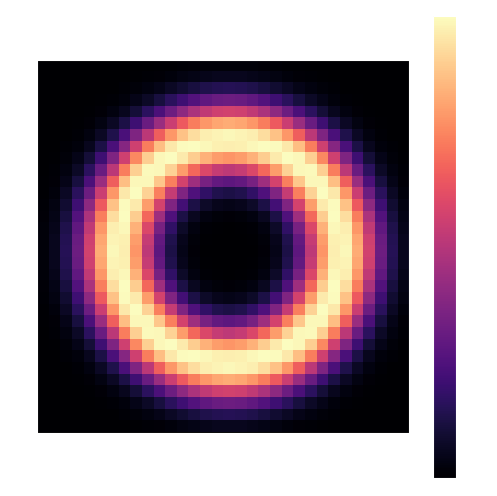

In [5]:
from functools import partial

def make_rings(x, y, radius = 10, sigma = 3, center = 32//2): 
    """
    x and y are arrays created from a np.meshgrid. 
    """
    r =  np.sqrt((x-center) ** 2 + (y - center) ** 2)
    return np.exp( - (r - radius) ** 2 / sigma)

x = np.arange(0, 32) / 32
y = np.arange(0, 32) / 32
X, Y = np.meshgrid(x,y)

ring = make_rings(X, Y, sigma = 1e-2, radius = 0.3, center = 0.5)

fig, axs = plt.subplots(1, 1, figsize = (6, 6))

im = axs.imshow(ring, cmap = "magma", vmin = 0, vmax = 1)
plt.colorbar(im)

Now, sample the ring parameters from uniform prior distributions

In [6]:
from tqdm import tqdm 
prior_params_config = {
    "radius": {"low": 0.1, "high": 0.3}, 
    "sigma": {"low": 1e-4, "high": 1e-2}
}

radius_prior = prior_params_config["radius"]
sigma_prior = prior_params_config["sigma"]
prior_sampler_radius = lambda size: np.random.uniform(radius_prior["low"], radius_prior["high"], size = size)
prior_sampler_sigma = lambda size: np.random.uniform(sigma_prior["low"], sigma_prior["high"], size = size)

dataset_size = 10_000

# Creating latent factors
radius = prior_sampler_radius(size = dataset_size)
sigma = prior_sampler_sigma(size = dataset_size)
theta = np.stack([radius, sigma]).T

# Creating simulations from it 
images = []
for params in tqdm(theta): 
    image = make_rings(X, Y, radius = params[0], sigma = params[1], center = 0.5)
    images.append(image) 

images = np.array(images)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:00<00:00, 54999.33it/s]


### Saving the dataset. 

In [7]:
from datasets import Dataset
dset = Dataset.from_dict({
            "theta": theta,
            "image": images 
        })
dset.save_to_disk("/home/noedia/links/scratch/crl/experiments/rings/data")

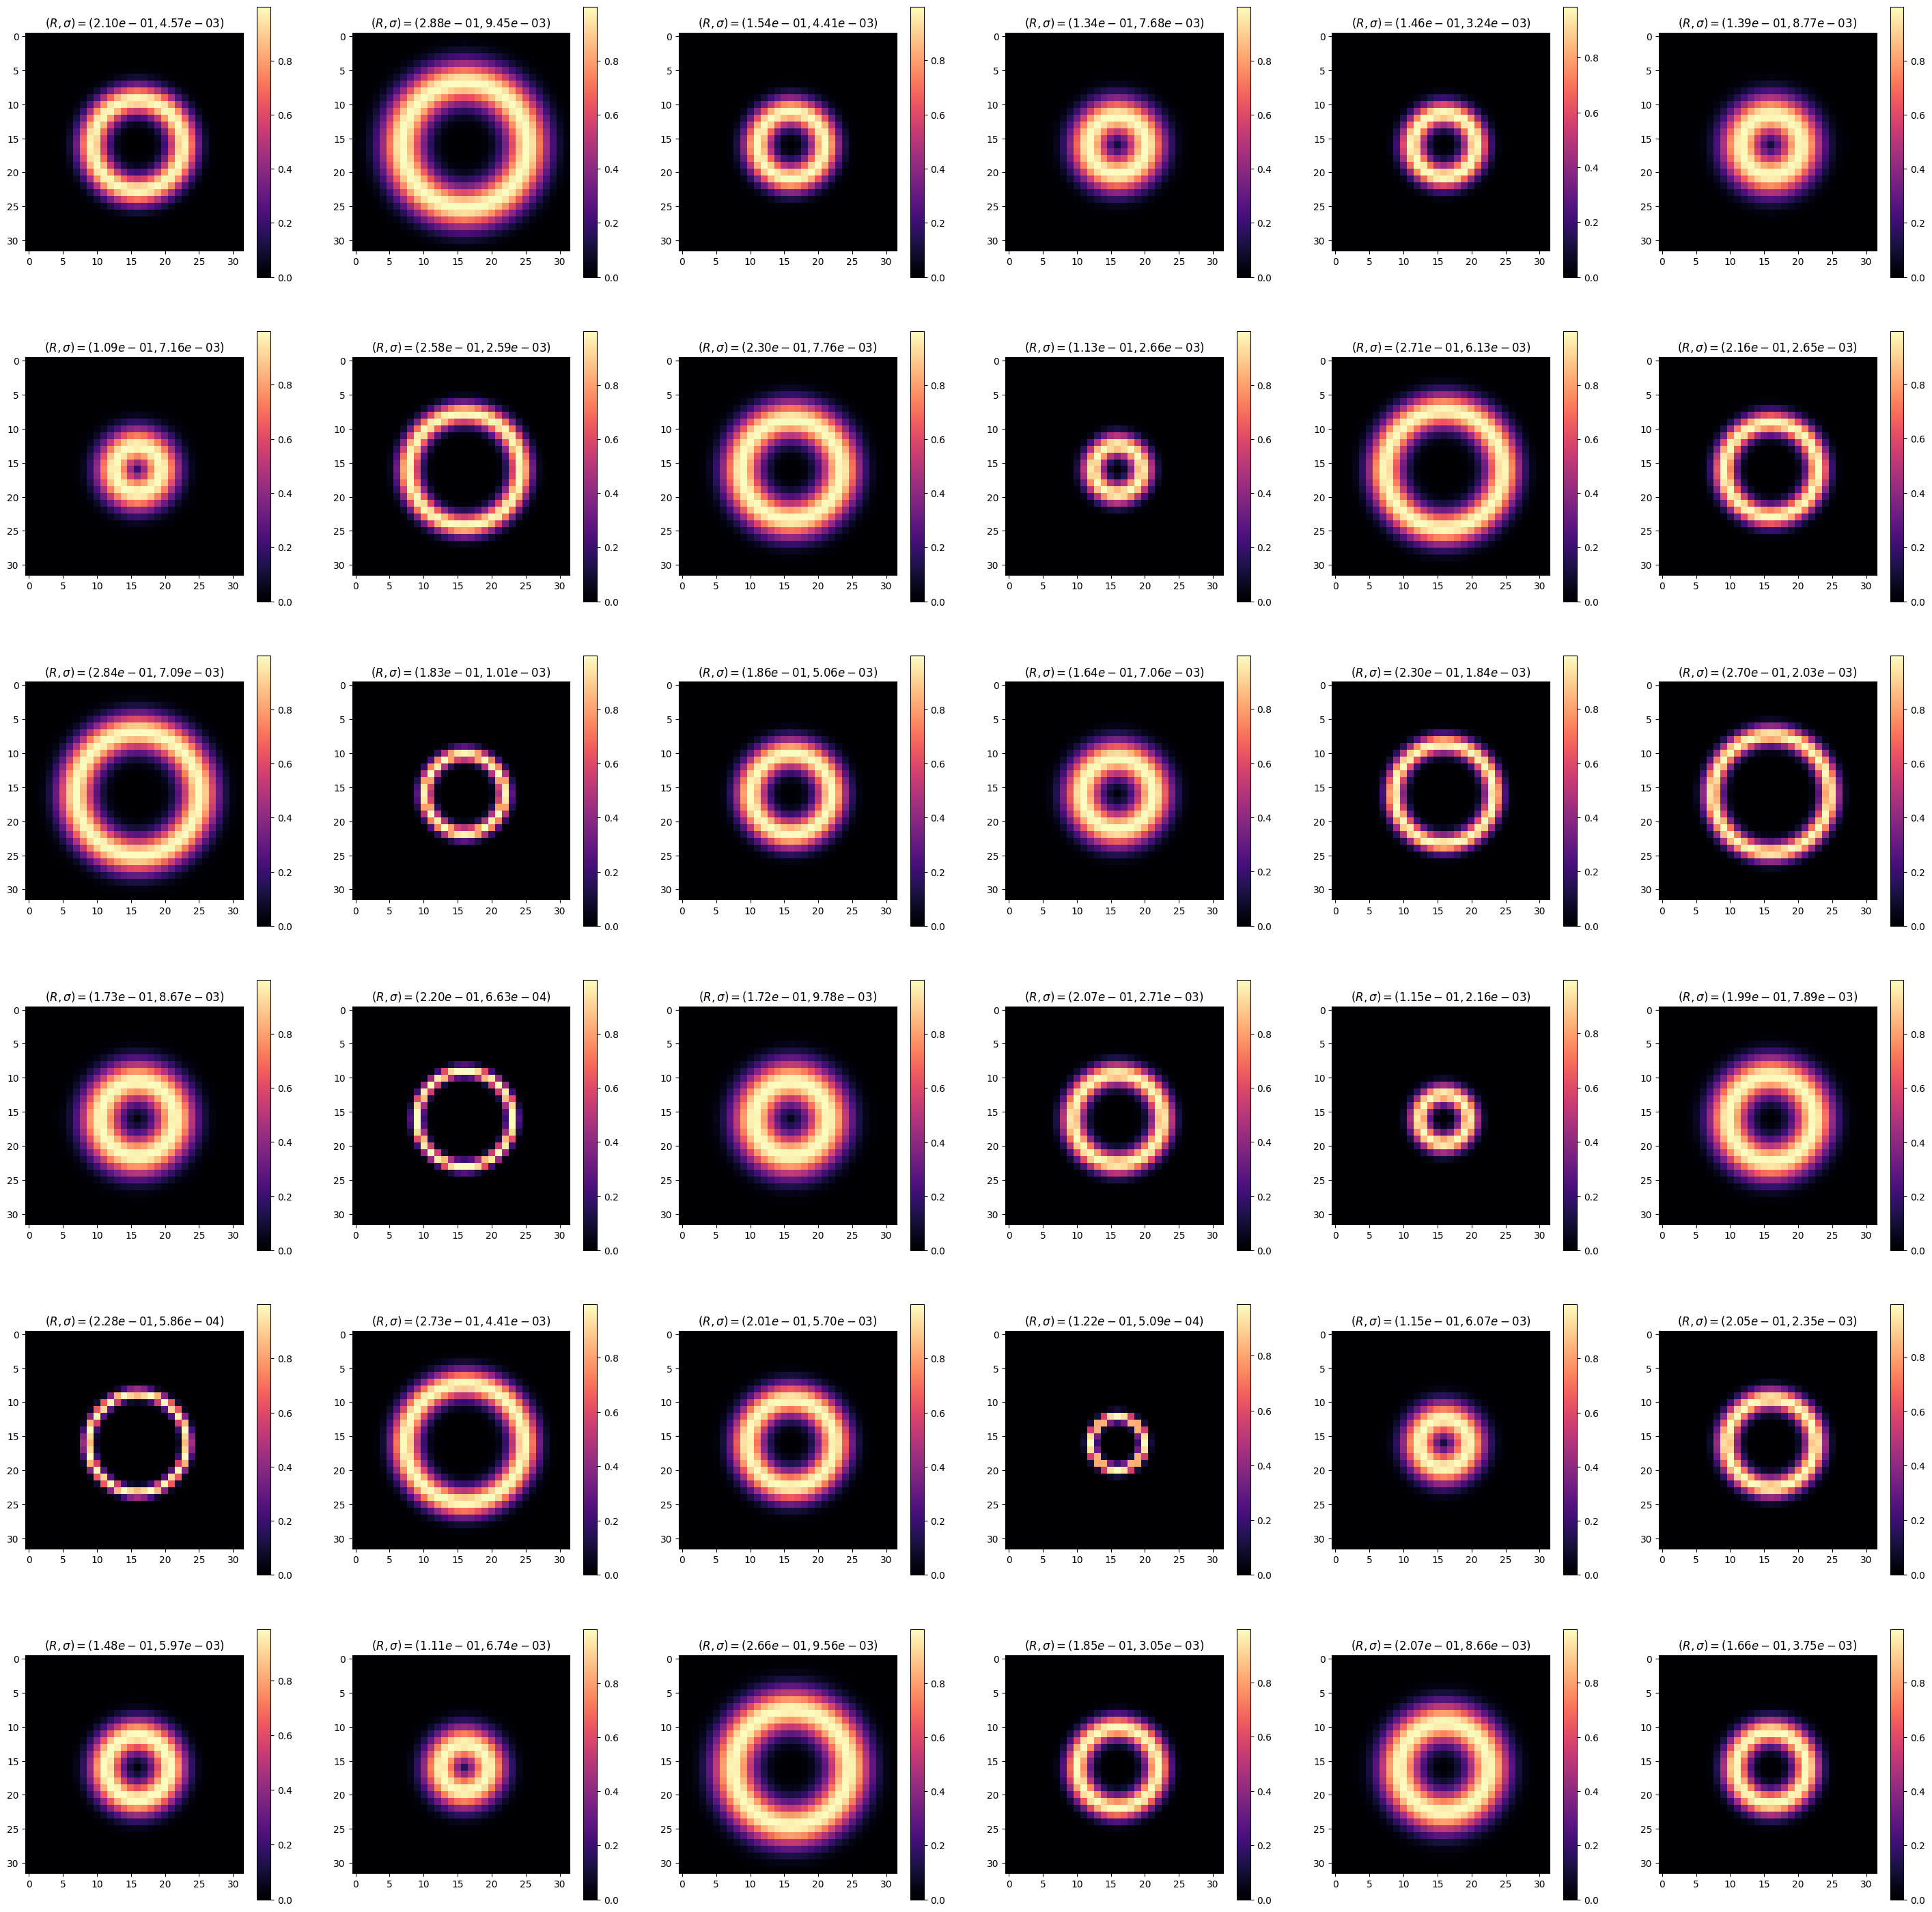

In [ ]:
fig, axs = plt.subplots(6, 6, figsize= (6 * 6, 6 * 6))

rings = images[:36]

for i, ax in enumerate(axs.flatten()): 
    im = ax.imshow(rings[i], cmap = "magma", vmin = 0)
    params = theta[i]
    ax.set_title(r"$(R, \sigma) = (%.2e,%.2e)$"%(params[0], params[1]))
    plt.colorbar(im, ax = ax)

In [ ]:
images.shape

(10000, 32, 32)

In [ ]:
theta

array([[ 2.51924828,  1.32726946],
       [11.25608679,  2.94860188],
       [25.30580591,  3.55337543],
       ...,
       [16.83613704,  4.68497306],
       [11.77987747,  2.38560095],
       [15.44827074,  4.26264754]], shape=(10000, 2))

In [6]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'

prior_params_config = {
        "radius": {"low": 2, "high": 0.43}, 
        "sigma": {"low": 0.5, "high": 5}
    }

radius_prior = prior_params_config["radius"]
sigma_prior = prior_params_config["sigma"]
prior_sampler_radius = lambda size: np.random.uniform(radius_prior["low"], radius_prior["high"], size = size)
prior_sampler_sigma = lambda size: np.random.uniform(sigma_prior["low"], sigma_prior["high"], size = size)

dataset_size = 10000

# Creating latent factors
radius = (prior_sampler_radius(size = dataset_size) - radius_prior["low"]) / (radius_prior["high"] - radius_prior["low"])
sigma = (prior_sampler_sigma(size = dataset_size) - sigma_prior["low"]) / (sigma_prior["high"] - sigma_prior["low"])

(array([1002.,  957.,  968., 1014.,  976., 1028., 1012., 1001., 1004.,
        1038.]),
 array([8.25067039e-06, 9.99991528e-02, 1.99990055e-01, 2.99980957e-01,
        3.99971859e-01, 4.99962761e-01, 5.99953663e-01, 6.99944565e-01,
        7.99935467e-01, 8.99926369e-01, 9.99917272e-01]),
 <BarContainer object of 10 artists>)

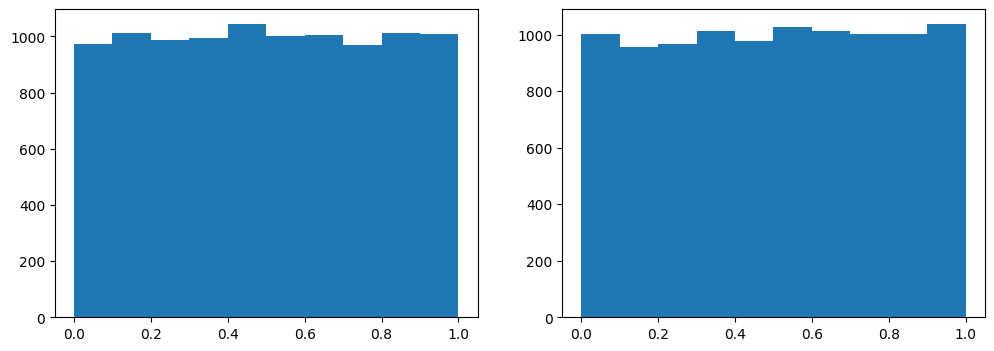

In [7]:
fig, axs = plt.subplots(1, 2, figsize = (12, 4))

ax = axs[0]
ax.hist(radius)

ax = axs[1]
ax.hist(sigma)